# Benchmarks with the penalty and the null-space connections

The `panels` models of the benchmark notebooks are compared with the two methods of imposing the multidomain connections, see the documentation page *Exact connections with the null-space method*:

- **penalty**: `conn_method='penalty'`, the penalty stiffnesses used by the notebooks, raised 100 times for the `'SSxcte'` edges of the DCB, see `dcb_utils.build_dcb`, and the default `calc_kt_kr` constant for the `'SB'` bond;
- **null-space**: `conn_method='null-space'`, the `'SSxcte'`, `'SSycte'`, `'BFxcte'`, `'BFycte'` and `'SB'` connections imposed exactly.

The cohesive zone `'SB_TSL'` and the prescribed displacements of the arms are penalty stiffnesses in both cases. All the models use the classical laminated plate theory (CLPT).

The null-space results are produced by `conn_method_study.py`, which takes the cases, discretisations and openings from the notebooks themselves, and saves them in `results/conn_methods/`:

```
python notebooks/conn_method_study.py run --jobs 8 --methods null-space
python notebooks/conn_method_study.py compliance
python notebooks/conn_method_study.py stamatelos
```

The penalty results of the DCB are the results stored in `results/*.npz`, loaded by the notebooks. Four of them were run again with the current code, see the section *Reproducibility of the stored penalty results*. The elastic compliances and the Stamatelos and Labeas models are fast and are computed with both methods.

In [1]:
import json
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.insert(0, os.path.abspath('.'))
import dcb_utils as du
import conn_method_study as study

R = 'results'
OUT = os.path.join(R, 'conn_methods')
jobs, compliances = study.collect()
jobs = sorted(jobs, key=lambda j: (j['notebook'], j['name']))


def load(path):
    if not os.path.exists(path):
        return None
    r = du.load(path)
    return r if len(r['delta']) else None


def curve(r):
    return np.r_[0., r['delta']], np.r_[0., r['P']]


def complete(r, job):
    return r is not None and np.isclose(r['delta'][-1], job['openings'][-1])


pct = lambda a, b: 100*(a/b - 1)
res = {j['name']: dict(penalty=load(os.path.join(R, j['name'] + '.npz')),
                       null=load(os.path.join(study.method_dir('null-space'), j['name'] + '.npz')))
       for j in jobs}

## Reproducibility of the stored penalty results

The penalty runs of the four longest cases were started again with the current code, and stopped after 23 to 33 of their 40 or 60 openings, beyond the onset of the damage. They reproduce the stored results to the round-off, so that the stored results are used as the penalty results below.

In [2]:
rows = ['| case | openings rerun | max. $|P/P_{stored} - 1|$ | max. $|a - a_{stored}|$ (mm) | max. $d$ at the last opening rerun |',
        '|---|---|---|---|---|']
for name in sorted(os.listdir(study.method_dir('penalty'))):
    if not name.endswith('.npz'):
        continue
    r = du.load(os.path.join(study.method_dir('penalty'), name))
    st = du.load(os.path.join(R, name))
    k = len(r['P'])
    rows.append(f"| {name[:-4]} | {k} of {len(st['P'])} | {np.abs(r['P']/st['P'][:k] - 1).max():.1e} "
                f"| {np.abs(r['a'] - st['a'][:k]).max():.1e} | {r['dmax'][-1]:.3f} |")
display(Markdown('\n'.join(rows)))

| case | openings rerun | max. $|P/P_{stored} - 1|$ | max. $|a - a_{stored}|$ (mm) | max. $d$ at the last opening rerun |
|---|---|---|---|---|
| alfano2001_TableI_to1.7 | 23 of 40 | 2.7e-10 | 0.0e+00 | 1.000 |
| alfano2001_TableI_to57 | 33 of 60 | 1.1e-10 | 0.0e+00 | 0.989 |
| camanho2003_DCB_AS4PEEK | 30 of 60 | 0.0e+00 | 0.0e+00 | 0.950 |
| turon2007_le0.125_tau60 | 30 of 60 | 0.0e+00 | 0.0e+00 | 0.919 |

## DCB: peak loads

For each case: the peak load $P_{max}$ and the initial stiffness $K_0$ of `dcb_utils.summary`, the crack growth $\Delta a$ at the last opening, the number of bisections of the increments and the run time. The differences are those of the null-space method with respect to the penalty method. Runs not yet complete show the openings reached and the peak of those openings, marked with \*.

In [3]:
rows = ['| case | openings | penalty $P_{max}$ (N) | null-space $P_{max}$ (N) | diff. (%) '
        '| $K_0$ diff. (%) | $\\Delta a$ penalty / null-space (mm) | bisections | time penalty / null-space (h) |',
        '|---|---|---|---|---|---|---|---|---|']
table = {}
for j in jobs:
    name, n = j['name'], len(j['openings'])
    rp, rn = res[name]['penalty'], res[name]['null']
    sp = du.summary(*curve(rp))
    sn = du.summary(*curve(rn)) if rn is not None else None
    done = complete(rn, j)
    table[name] = dict(penalty=sp, null=sn, done=done)
    k = 0 if rn is None else len(rn['delta'])
    Pn = '-' if sn is None else '%.2f%s' % (sn['Pmax'], '' if done else '*')
    dP = '%+.3f' % pct(sn['Pmax'], sp['Pmax']) if done else '-'
    dK = '%+.3f' % pct(sn['K0'], sp['K0']) if done else '-'
    da = '%.1f / %s' % (rp['a'][-1] - j['case']['a0'], '-' if rn is None else '%.1f' % (rn['a'][-1] - j['case']['a0']))
    bis = '%d / %s' % (rp['failed'], '-' if rn is None else '%d' % rn['failed'])
    tt = '%.1f / %s' % (float(rp['time'])/3600, '-' if rn is None else '%.1f' % (float(rn['time'])/3600))
    rows.append(f"| {name} | {k} of {n} | {sp['Pmax']:.2f} | {Pn} | {dP} | {dK} | {da} | {bis} | {tt} |")
display(Markdown('\n'.join(rows)))

| case | openings | penalty $P_{max}$ (N) | null-space $P_{max}$ (N) | diff. (%) | $K_0$ diff. (%) | $\Delta a$ penalty / null-space (mm) | bisections | time penalty / null-space (h) |
|---|---|---|---|---|---|---|---|---|
| alfano2001_TableII_XAS913C | 60 of 60 | 93.77 | 93.74 | -0.028 | +0.131 | 10.6 / 10.7 | 0 / 0 | 2.1 / 3.4 |
| alfano2001_TableI_to1.7 | 40 of 40 | 50.92 | 50.93 | +0.009 | +0.066 | 5.8 / 5.8 | 0 / 0 | 7.4 / 2.2 |
| alfano2001_TableI_to57 | 60 of 60 | 64.57 | 64.58 | +0.009 | +0.131 | 10.5 / 10.5 | 0 / 0 | 2.6 / 3.2 |
| camanho2003_DCB_AS4PEEK | 60 of 60 | 139.89 | 139.88 | -0.009 | +0.122 | 8.2 / 8.2 | 0 / 0 | 2.6 / 3.1 |
| krueger2008_DCB_MD_tau40 | 60 of 60 | 108.67 | 108.64 | -0.022 | +0.153 | 7.6 / 7.6 | 0 / 0 | 1.5 / 2.1 |
| krueger2008_DCB_MD_tau60 | 60 of 60 | 109.95 | 109.95 | +0.005 | +0.161 | 11.4 / 11.4 | 0 / 0 | 1.8 / 2.5 |
| krueger2008_DCB_UD_tau40 | 60 of 60 | 63.60 | 63.62 | +0.023 | +0.130 | 9.9 / 9.9 | 0 / 0 | 1.8 / 2.7 |
| krueger2008_DCB_UD_tau60 | 60 of 60 | 64.25 | 64.24 | -0.006 | +0.133 | 11.8 / 11.8 | 0 / 0 | 2.0 / 2.9 |
| tijs2022_a40 | 60 of 60 | 197.49 | 197.48 | -0.008 | +0.135 | 11.8 / 11.8 | 0 / 0 | 2.2 / 3.2 |
| tijs2022_a48 | 60 of 60 | 166.20 | 166.21 | +0.010 | +0.115 | 11.8 / 11.8 | 0 / 0 | 2.4 / 3.3 |
| tijs2023_full_weld | 60 of 60 | 148.27 | 148.25 | -0.015 | +0.131 | 4.9 / 4.9 | 0 / 0 | 2.0 / 2.2 |
| tijs2023_weld_center | 60 of 60 | 119.20 | 119.22 | +0.010 | +0.151 | 5.2 / 5.2 | 0 / 0 | 2.1 / 2.2 |
| tijs2023_weld_center_autoclave | 60 of 60 | 87.79 | 87.79 | +0.008 | +0.156 | 9.2 / 9.2 | 0 / 0 | 2.3 / 3.1 |
| tijs2023_weld_center_standard | 60 of 60 | 115.00 | 115.00 | -0.000 | +0.151 | 5.7 / 5.7 | 0 / 0 | 2.1 / 2.4 |
| turon2007_le0.125_tau60 | 60 of 60 | 64.07 | 64.08 | +0.012 | +0.098 | 13.0 / 13.0 | 0 / 0 | 2.7 / 3.3 |
| turon2007_le0.125_tau60_K1e6 | 60 of 60 | 64.05 | 64.04 | -0.013 | +0.098 | 6.5 / 6.7 | 0 / 0 | 1.8 / 2.3 |

## DCB: load-opening curves

The difference between the curves is the largest difference of the load at the same opening, relative to the peak load of the penalty method, before and after the peak.

In [4]:
rows = ['| case | openings compared | before the peak, max. $|P_{null} - P_{pen}|/P_{max}$ (%) | after the peak (%) |',
        '|---|---|---|---|']
for j in jobs:
    rp, rn = res[j['name']]['penalty'], res[j['name']]['null']
    if rn is None:
        continue
    k = len(rn['P'])
    ipk = int(np.argmax(rp['P']))
    d = 100*np.abs(rn['P'] - rp['P'][:k])/rp['P'].max()
    pre = d[:min(ipk + 1, k)].max()
    post = '%.3f' % d[ipk + 1:].max() if k > ipk + 1 else '-'
    rows.append(f"| {j['name']} | {k} of {len(rp['P'])} | {pre:.3f} | {post} |")
display(Markdown('\n'.join(rows)))

| case | openings compared | before the peak, max. $|P_{null} - P_{pen}|/P_{max}$ (%) | after the peak (%) |
|---|---|---|---|
| alfano2001_TableII_XAS913C | 60 of 60 | 0.103 | 0.083 |
| alfano2001_TableI_to1.7 | 40 of 40 | 0.043 | 0.036 |
| alfano2001_TableI_to57 | 60 of 60 | 0.102 | 0.065 |
| camanho2003_DCB_AS4PEEK | 60 of 60 | 0.096 | 0.228 |
| krueger2008_DCB_MD_tau40 | 60 of 60 | 0.113 | 0.087 |
| krueger2008_DCB_MD_tau60 | 60 of 60 | 0.120 | 0.093 |
| krueger2008_DCB_UD_tau40 | 60 of 60 | 0.101 | 0.083 |
| krueger2008_DCB_UD_tau60 | 60 of 60 | 0.106 | 0.069 |
| tijs2022_a40 | 60 of 60 | 0.104 | 0.102 |
| tijs2022_a48 | 60 of 60 | 0.091 | 0.086 |
| tijs2023_full_weld | 60 of 60 | 0.096 | 0.059 |
| tijs2023_weld_center | 60 of 60 | 0.112 | 0.117 |
| tijs2023_weld_center_autoclave | 60 of 60 | 0.117 | 0.098 |
| tijs2023_weld_center_standard | 60 of 60 | 0.112 | 0.188 |
| turon2007_le0.125_tau60 | 60 of 60 | 0.079 | 0.098 |
| turon2007_le0.125_tau60_K1e6 | 60 of 60 | 0.079 | 0.098 |

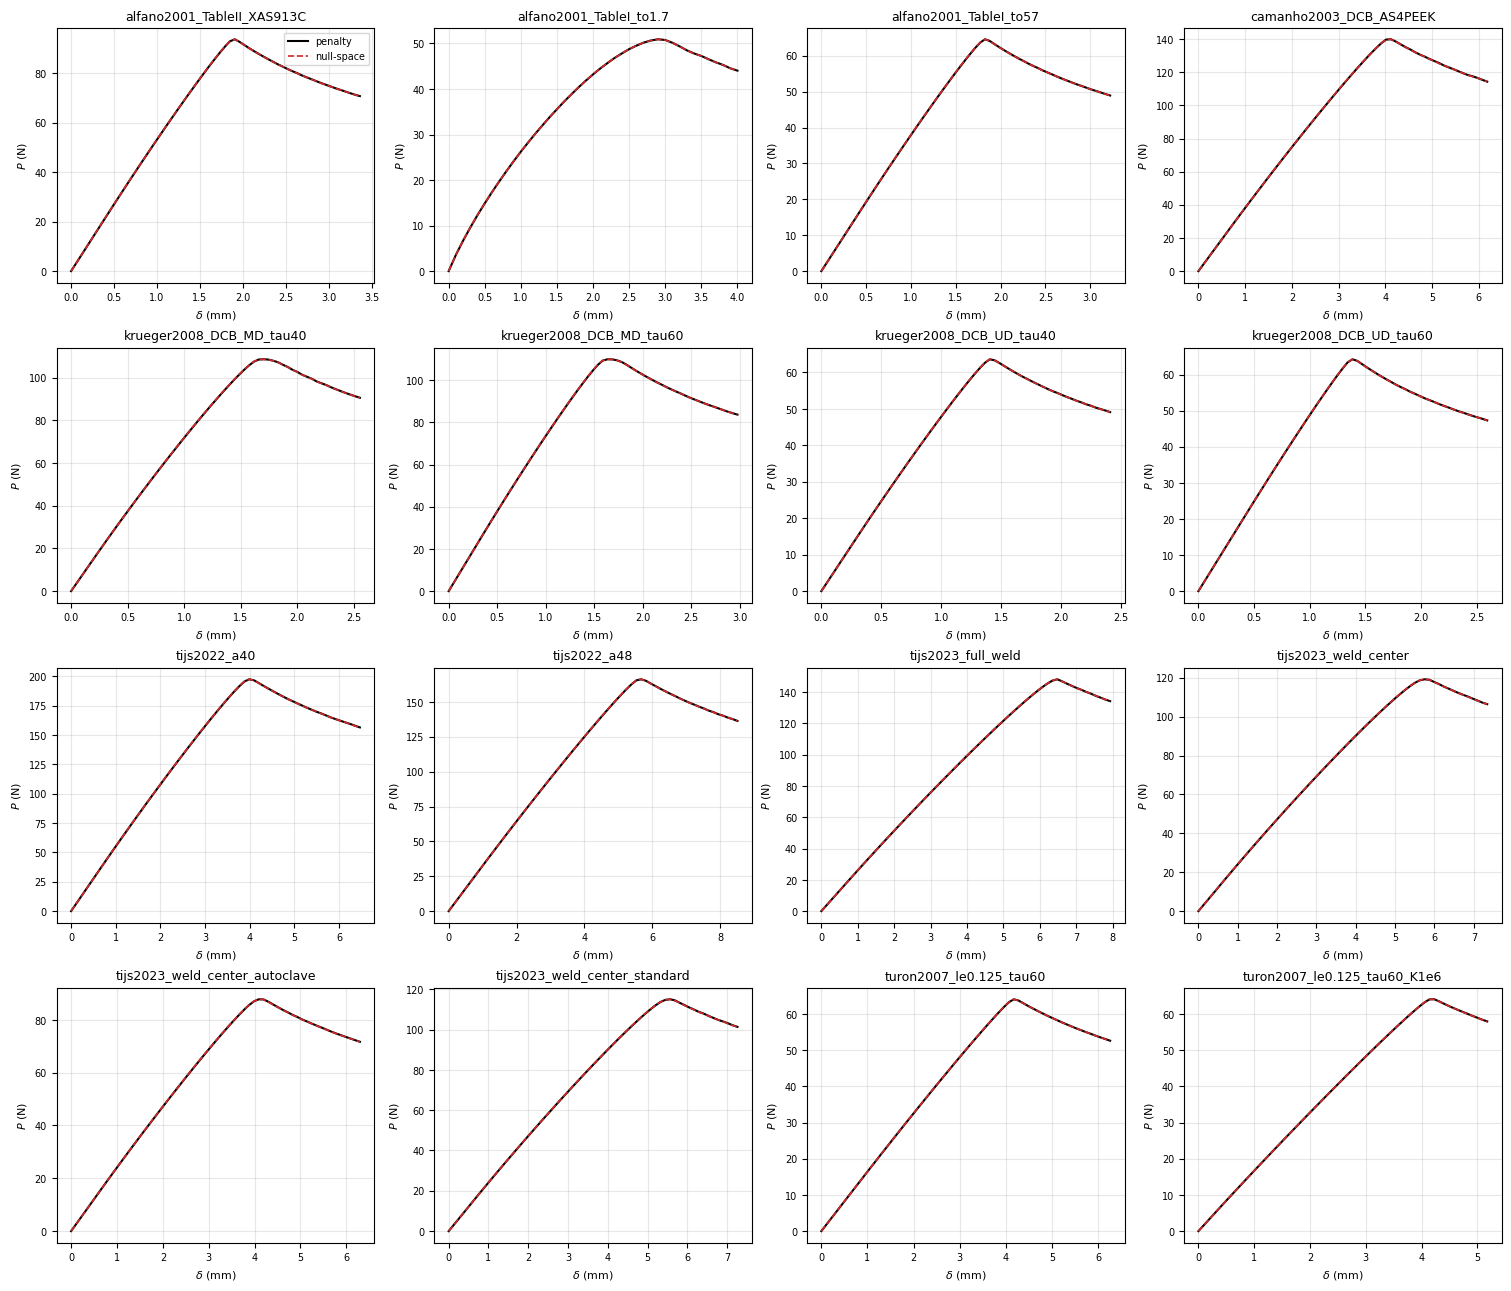

In [5]:
n = len(jobs)
ncol = 4
fig, axes = plt.subplots(int(np.ceil(n/ncol)), ncol, figsize=(15, 3.2*np.ceil(n/ncol)),
                         constrained_layout=True)
for ax, j in zip(axes.ravel(), jobs):
    rp, rn = res[j['name']]['penalty'], res[j['name']]['null']
    ax.plot(*curve(rp), color='k', lw=1.5, label='penalty')
    if rn is not None:
        ax.plot(*curve(rn), color='C3', lw=1.2, ls='--', label='null-space')
    ax.set_title(j['name'], fontsize=9)
    ax.set_xlabel(r'$\delta$ (mm)', fontsize=8)
    ax.set_ylabel('$P$ (N)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
axes.ravel()[0].legend(fontsize=7)
for ax in axes.ravel()[n:]:
    ax.axis('off')
plt.show()

## DCB: elastic compliances

`dcb_utils.elastic_compliance` of `lecinana2023_dcb.ipynb` and of the calibration of `tijs2023_phd_dcb.ipynb`, a single opening well below the damage onset.

In [6]:
path = os.path.join(OUT, 'compliance.json')
if os.path.exists(path):
    comp = json.load(open(path))
    rows = ['| notebook | $a_0$ (mm) | penalty (mm/N) | null-space (mm/N) | diff. (%) |', '|---|---|---|---|---|']
    for c in comp:
        rows.append(f"| {c['notebook']} | {c['a0']:.2f} | {c['penalty']:.6f} | {c['null-space']:.6f} "
                    f"| {pct(c['null-space'], c['penalty']):+.3f} |")
    display(Markdown('\n'.join(rows)))

| notebook | $a_0$ (mm) | penalty (mm/N) | null-space (mm/N) | diff. (%) |
|---|---|---|---|---|
| tijs2023_phd_dcb.ipynb | 30.00 | 0.007848 | 0.007833 | -0.186 |
| tijs2023_phd_dcb.ipynb | 35.00 | 0.012259 | 0.012239 | -0.162 |
| tijs2023_phd_dcb.ipynb | 40.00 | 0.018076 | 0.018050 | -0.144 |
| tijs2023_phd_dcb.ipynb | 45.00 | 0.025492 | 0.025459 | -0.129 |
| tijs2023_phd_dcb.ipynb | 30.00 | 0.012343 | 0.012317 | -0.208 |
| tijs2023_phd_dcb.ipynb | 35.00 | 0.019270 | 0.019235 | -0.181 |
| tijs2023_phd_dcb.ipynb | 40.00 | 0.028417 | 0.028372 | -0.161 |
| tijs2023_phd_dcb.ipynb | 45.00 | 0.040097 | 0.040039 | -0.145 |
| tijs2023_phd_dcb.ipynb | 30.00 | 0.023891 | 0.023843 | -0.200 |
| tijs2023_phd_dcb.ipynb | 35.00 | 0.037480 | 0.037415 | -0.174 |
| tijs2023_phd_dcb.ipynb | 40.00 | 0.055445 | 0.055360 | -0.154 |
| tijs2023_phd_dcb.ipynb | 45.00 | 0.078399 | 0.078290 | -0.139 |
| lecinana2023_dcb.ipynb | 32.05 | 0.009551 | 0.009535 | -0.173 |
| lecinana2023_dcb.ipynb | 33.40 | 0.010763 | 0.010745 | -0.167 |
| lecinana2023_dcb.ipynb | 35.93 | 0.013301 | 0.013281 | -0.156 |
| lecinana2023_dcb.ipynb | 38.05 | 0.015713 | 0.015690 | -0.148 |
| lecinana2023_dcb.ipynb | 42.97 | 0.022398 | 0.022368 | -0.133 |

## DCB: computational cost

The wall times of the runs cannot be compared directly: the stored penalty results were run by the notebooks at different times, the penalty reruns with 7 runs in parallel and the null-space runs with 8, on 8 physical cores, partly together with the profiling below. The cost is instead measured by component, with `python notebooks/conn_method_study.py profile` (`profile_case` and `profile_panels`, saved in `results/conn_methods/profile.json`):

- each component of a Newton-Raphson iteration of `dcb_utils.solve_dcb` is timed for each case, with both methods one after the other, at the linear solution at the opening of the stored peak load, where the damage grows ahead of the crack tip;
- `kT_pan` is the tangent stiffness of the panels, `calc_kT`, with the nonlinear terms of CLPT; `residual` is `get_kC_conn` plus `calc_fint`; `kT_TSL` the damage-rate stiffness of the cohesive zone; `reduce` the product $T^T K T$, the sum of the matrices and the products of the vectors by $T$; `solve` the sparse solution of `structsolve.solve`; `T` the construction of the null-space basis, once per run;
- the profiling ran while the null-space runs were using the 8 cores, so the absolute times are those of a loaded machine; the two methods of each case were timed under the same load.

The cost of a run follows from these timings and from the number of calls of each component, given by the iterations of each opening and the rules of `solve_dcb`, see `conn_method_study.iteration_counts` and `conn_method_study.predicted_cost`.

In [7]:
PR = json.load(open(os.path.join(OUT, 'profile.json')))
IT = PR['iterations']
names = sorted(j['name'] for j in jobs)
bond = {j['name']: j['case'].get('bond_width') for j in jobs}
per_res = lambda t: t['kC_conn'] + t['fint']
per_red = lambda t: t['reduce'] + t['sum'] + t['vec']
rest = lambda t: per_res(t) + t['kT_TSL'] + per_red(t) + t['solve']
rows = ['| case | unknowns penalty / null-space | nonzeros of the system (M) | `T` (s) | `kT_pan` penalty / null-space (s) '
        '| `residual` (s) | `kT_TSL` (s) | `reduce` (s) | `solve` (s) | iteration without `kT_pan` (s) | diff. (%) |',
        '|---|---|---|---|---|---|---|---|---|---|---|']
for name in names:
    p, n = IT[name + '|penalty'], IT[name + '|null-space']
    tp, tn = p['t'], n['t']
    rows.append(f"| {name} | {p['size']} / {n['size_r']} | {p['nnz_k0']/1e6:.2f} / {n['nnz_k0']/1e6:.2f} | {n['t_T']:.3f} "
                f"| {tp['kT_pan']:.1f} / {tn['kT_pan']:.1f} | {per_res(tp):.2f} / {per_res(tn):.2f} "
                f"| {tp['kT_TSL']:.2f} / {tn['kT_TSL']:.2f} | - / {per_red(tn):.3f} | {tp['solve']:.2f} / {tn['solve']:.2f} "
                f"| {rest(tp):.2f} / {rest(tn):.2f} | {pct(rest(tn), rest(tp)):+.1f} |")
display(Markdown('\n'.join(rows)))
kTs = np.array([[IT[nm + '|' + m]['t']['kT_pan'] for m in ('penalty', 'null-space')] for nm in names])
print('kT_pan: %.1f to %.1f s; null-space / penalty %.3f to %.3f, the same computation, the spread is the load of the machine'
      % (kTs.min(), kTs.max(), (kTs[:, 1]/kTs[:, 0]).min(), (kTs[:, 1]/kTs[:, 0]).max()))

| case | unknowns penalty / null-space | nonzeros of the system (M) | `T` (s) | `kT_pan` penalty / null-space (s) | `residual` (s) | `kT_TSL` (s) | `reduce` (s) | `solve` (s) | iteration without `kT_pan` (s) | diff. (%) |
|---|---|---|---|---|---|---|---|---|---|---|
| alfano2001_TableII_XAS913C | 2268 / 1948 | 2.13 / 1.98 | 0.039 | 80.2 / 81.2 | 2.32 / 2.17 | 0.63 / 0.60 | - / 0.150 | 0.57 / 0.35 | 3.57 / 3.27 | -8.2 |
| alfano2001_TableI_to1.7 | 1884 / 1804 | 1.85 / 1.79 | 0.009 | 78.6 / 89.0 | 2.08 / 1.91 | 0.28 / 0.30 | - / 0.141 | 0.44 / 0.36 | 2.84 / 2.72 | -4.4 |
| alfano2001_TableI_to57 | 2268 / 1948 | 2.13 / 2.01 | 0.035 | 86.8 / 79.9 | 2.53 / 2.47 | 0.60 / 0.63 | - / 0.162 | 0.55 / 0.45 | 3.73 / 3.71 | -0.4 |
| camanho2003_DCB_AS4PEEK | 2268 / 1948 | 2.13 / 1.99 | 0.039 | 79.0 / 87.3 | 2.45 / 2.50 | 0.51 / 0.56 | - / 0.174 | 0.66 / 0.57 | 3.68 / 3.80 | +3.2 |
| krueger2008_DCB_MD_tau40 | 2268 / 1948 | 2.18 / 2.04 | 0.031 | 79.4 / 81.6 | 2.63 / 1.95 | 0.34 / 0.30 | - / 0.148 | 0.70 / 0.41 | 3.72 / 2.81 | -24.5 |
| krueger2008_DCB_MD_tau60 | 2268 / 1948 | 2.18 / 2.04 | 0.035 | 80.3 / 76.9 | 2.26 / 2.16 | 0.53 / 0.63 | - / 0.189 | 0.58 / 0.46 | 3.43 / 3.43 | +0.1 |
| krueger2008_DCB_UD_tau40 | 2268 / 1948 | 2.13 / 1.99 | 0.030 | 77.2 / 71.5 | 2.21 / 1.94 | 0.50 / 0.45 | - / 0.148 | 0.52 / 0.39 | 3.27 / 2.93 | -10.3 |
| krueger2008_DCB_UD_tau60 | 2268 / 1948 | 2.13 / 1.99 | 0.028 | 82.1 / 79.1 | 2.07 / 2.28 | 0.54 / 0.65 | - / 0.158 | 0.48 / 0.41 | 3.13 / 3.50 | +11.8 |
| tijs2022_a40 | 2268 / 1948 | 2.13 / 2.03 | 0.029 | 78.9 / 82.6 | 2.40 / 2.26 | 0.46 / 0.42 | - / 0.142 | 0.58 / 0.42 | 3.49 / 3.23 | -7.4 |
| tijs2022_a48 | 2268 / 1948 | 2.13 / 2.04 | 0.037 | 91.7 / 85.8 | 2.23 / 2.16 | 0.49 / 0.48 | - / 0.149 | 0.60 / 0.42 | 3.36 / 3.21 | -4.5 |
| tijs2023_full_weld | 2268 / 1948 | 2.18 / 2.02 | 0.027 | 84.3 / 78.6 | 2.62 / 2.75 | 0.25 / 0.27 | - / 0.169 | 0.59 / 0.40 | 3.50 / 3.60 | +2.8 |
| tijs2023_weld_center | 2268 / 1948 | 2.18 / 2.09 | 0.032 | 81.5 / 83.1 | 2.25 / 2.07 | 0.33 / 0.30 | - / 0.162 | 0.67 / 0.42 | 3.29 / 2.96 | -10.1 |
| tijs2023_weld_center_autoclave | 2268 / 1948 | 2.18 / 2.09 | 0.040 | 86.7 / 80.5 | 2.21 / 2.21 | 0.45 / 0.41 | - / 0.181 | 0.74 / 0.54 | 3.45 / 3.35 | -2.9 |
| tijs2023_weld_center_standard | 2268 / 1948 | 2.18 / 2.09 | 0.027 | 83.9 / 81.3 | 2.05 / 1.96 | 0.33 / 0.32 | - / 0.167 | 0.60 / 0.45 | 3.03 / 2.90 | -4.1 |
| turon2007_le0.125_tau60 | 2268 / 1948 | 2.13 / 2.00 | 0.039 | 79.7 / 87.2 | 2.94 / 2.69 | 0.83 / 0.64 | - / 0.177 | 0.74 / 0.46 | 4.58 / 3.96 | -13.5 |
| turon2007_le0.125_tau60_K1e6 | 2268 / 1948 | 2.13 / 1.99 | 0.033 | 79.8 / 78.9 | 2.42 / 2.12 | 0.47 / 0.40 | - / 0.145 | 0.63 / 0.39 | 3.58 / 3.05 | -14.8 |

kT_pan: 71.5 to 91.7 s; null-space / penalty 0.921 to 1.132, the same computation, the spread is the load of the machine


The tangent of the panels is computed by numerical integration of the nonlinear CLPT terms, `fkC_num` and `fkG_num`, on `nx = 2m` by `ny = 2n` points. Its cost grows as $n_x n_y (3 m n)^2$, so that it comes almost entirely from the two cohesive-zone panels, which have the largest numbers of terms:

In [8]:
for name, pans in PR['panels'].items():
    tot = sum(r['t_kC'] + r['t_kG'] for r in pans)
    rows = [f'**{name}**', '', '| panel | terms $m \\times n$ | points $n_x \\times n_y$ | `calc_kC` (s) | `calc_kG` (s) | share (%) |',
            '|---|---|---|---|---|---|']
    for r in pans:
        kind = 'cohesive zone' if r['tsl'] else 'arm / bonded'
        rows.append(f"| {r['group']}, {kind}, a = {r['a']:.1f} mm | {r['m']} x {r['n']} | {r['nx']} x {r['ny']} "
                    f"| {r['t_kC']:.2f} | {r['t_kG']:.2f} | {100*(r['t_kC'] + r['t_kG'])/tot:.1f} |")
    display(Markdown('\n'.join(rows)))
p = IT['turon2007_le0.125_tau60|penalty']
print('cProfile of one iteration without kT_pan, turon2007_le0.125_tau60, penalty:')
print('\n'.join(p['cprofile'].splitlines()[:22]))

**alfano2001_TableI_to1.7**

| panel | terms $m \times n$ | points $n_x \times n_y$ | `calc_kC` (s) | `calc_kG` (s) | share (%) |
|---|---|---|---|---|---|
| bot, cohesive zone, a = 70.0 mm | 25 x 10 | 50 x 20 | 17.57 | 16.88 | 49.0 |
| bot, arm / bonded, a = 30.0 mm | 8 x 8 | 16 x 16 | 0.28 | 0.18 | 0.6 |
| top, cohesive zone, a = 70.0 mm | 25 x 10 | 50 x 20 | 17.64 | 17.26 | 49.7 |
| top, arm / bonded, a = 30.0 mm | 8 x 8 | 16 x 16 | 0.30 | 0.16 | 0.7 |

**turon2007_le0.125_tau60**

| panel | terms $m \times n$ | points $n_x \times n_y$ | `calc_kC` (s) | `calc_kG` (s) | share (%) |
|---|---|---|---|---|---|
| bot, arm / bonded, a = 71.6 mm | 8 x 8 | 16 x 16 | 0.29 | 0.16 | 0.6 |
| bot, cohesive zone, a = 23.4 mm | 25 x 10 | 50 x 20 | 17.97 | 16.95 | 48.5 |
| bot, arm / bonded, a = 55.0 mm | 8 x 8 | 16 x 16 | 0.30 | 0.16 | 0.6 |
| top, arm / bonded, a = 71.6 mm | 8 x 8 | 16 x 16 | 0.29 | 0.19 | 0.7 |
| top, cohesive zone, a = 23.4 mm | 25 x 10 | 50 x 20 | 17.45 | 17.82 | 48.9 |
| top, arm / bonded, a = 55.0 mm | 8 x 8 | 16 x 16 | 0.30 | 0.16 | 0.6 |

cProfile of one iteration without kT_pan, turon2007_le0.125_tau60, penalty:
         14768 function calls (14730 primitive calls) in 4.558 seconds

   Ordered by: internal time
   List reduced from 344 to 12 due to restriction <12>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        6    1.538    0.256    1.542    0.257 panels/models/plate_clpt_donnell_num.pyx:873(calc_fint)
        1    0.601    0.601    0.601    0.601 {built-in method scipy.sparse.linalg._dsolve._superlu.gssv}
        7    0.565    0.081    0.565    0.081 {built-in method gc.collect}
        1    0.514    0.514    0.529    0.529 C:\Users\saullogiovanip\repos\panels\panels\multidomain\multidomain.py:2232(_kC_TSL)
        1    0.459    0.459    0.724    0.724 C:\Users\saullogiovanip\repos\panels\panels\multidomain\multidomain.py:2296(calc_kT_TSL)
        7    0.238    0.034    0.238    0.034 {built-in method scipy.sparse._sparsetools.csr_sort_indices}
        4    0.228    0.057    0.228   

### Cost of the runs

For each case, the cost of the runs is predicted at the openings reached by the null-space run, from its iterations and from those of the stored penalty run at the same openings. The tangent of the panels is given the mean of the timings of the two methods, since it is the same computation. The column *same iterations* uses the iterations of the penalty run for both methods, which isolates the cost of an iteration from the number of iterations.

| case | openings | iterations penalty / null-space | `kT_pan` calls penalty / null-space | penalty (h) | null-space (h) | diff. (%) | same iterations, diff. (%) | `kT_pan` share (%) |
|---|---|---|---|---|---|---|---|---|
| alfano2001_TableII_XAS913C | 60 | 208 / 216 | 124 / 127 | 3.03 | 3.08 | +1.8 | -0.65 | 91.8 |
| alfano2001_TableI_to1.7 | 40 | 104 / 104 | 80 / 80 | 1.97 | 1.96 | -0.3 | -0.28 | 94.6 |
| alfano2001_TableI_to57 | 60 | 204 / 201 | 119 / 116 | 3.01 | 2.94 | -2.5 | -0.05 | 91.5 |
| camanho2003_DCB_AS4PEEK | 60 | 192 / 191 | 121 / 117 | 3.03 | 2.95 | -2.8 | +0.26 | 92.1 |
| krueger2008_DCB_MD_tau40 | 60 | 147 / 148 | 98 / 99 | 2.39 | 2.36 | -1.1 | -2.04 | 91.7 |
| krueger2008_DCB_MD_tau60 | 60 | 193 / 195 | 113 / 114 | 2.69 | 2.71 | +0.8 | -0.06 | 91.7 |
| krueger2008_DCB_UD_tau40 | 60 | 187 / 195 | 114 / 120 | 2.56 | 2.67 | +4.2 | -0.86 | 91.9 |
| krueger2008_DCB_UD_tau60 | 60 | 226 / 227 | 125 / 126 | 3.03 | 3.08 | +1.7 | +0.89 | 92.3 |
| tijs2022_a40 | 60 | 186 / 196 | 110 / 120 | 2.69 | 2.91 | +8.1 | -0.60 | 91.7 |
| tijs2022_a48 | 60 | 193 / 193 | 122 / 122 | 3.23 | 3.22 | -0.3 | -0.30 | 93.2 |
| tijs2023_full_weld | 60 | 140 / 142 | 98 / 100 | 2.40 | 2.45 | +2.2 | +0.26 | 92.5 |
| tijs2023_weld_center | 60 | 148 / 147 | 103 / 100 | 2.53 | 2.44 | -3.4 | -0.66 | 93.1 |
| tijs2023_weld_center_autoclave | 60 | 179 / 181 | 112 / 113 | 2.81 | 2.83 | +0.7 | -0.18 | 92.5 |
| tijs2023_weld_center_standard | 60 | 156 / 159 | 105 / 106 | 2.58 | 2.59 | +0.7 | -0.27 | 93.5 |
| turon2007_le0.125_tau60 | 60 | 214 / 208 | 124 / 122 | 3.20 | 3.11 | -2.9 | -1.28 | 89.8 |
| turon2007_le0.125_tau60_K1e6 | 60 | 151 / 156 | 105 / 108 | 2.51 | 2.55 | +1.7 | -1.11 | 92.3 |

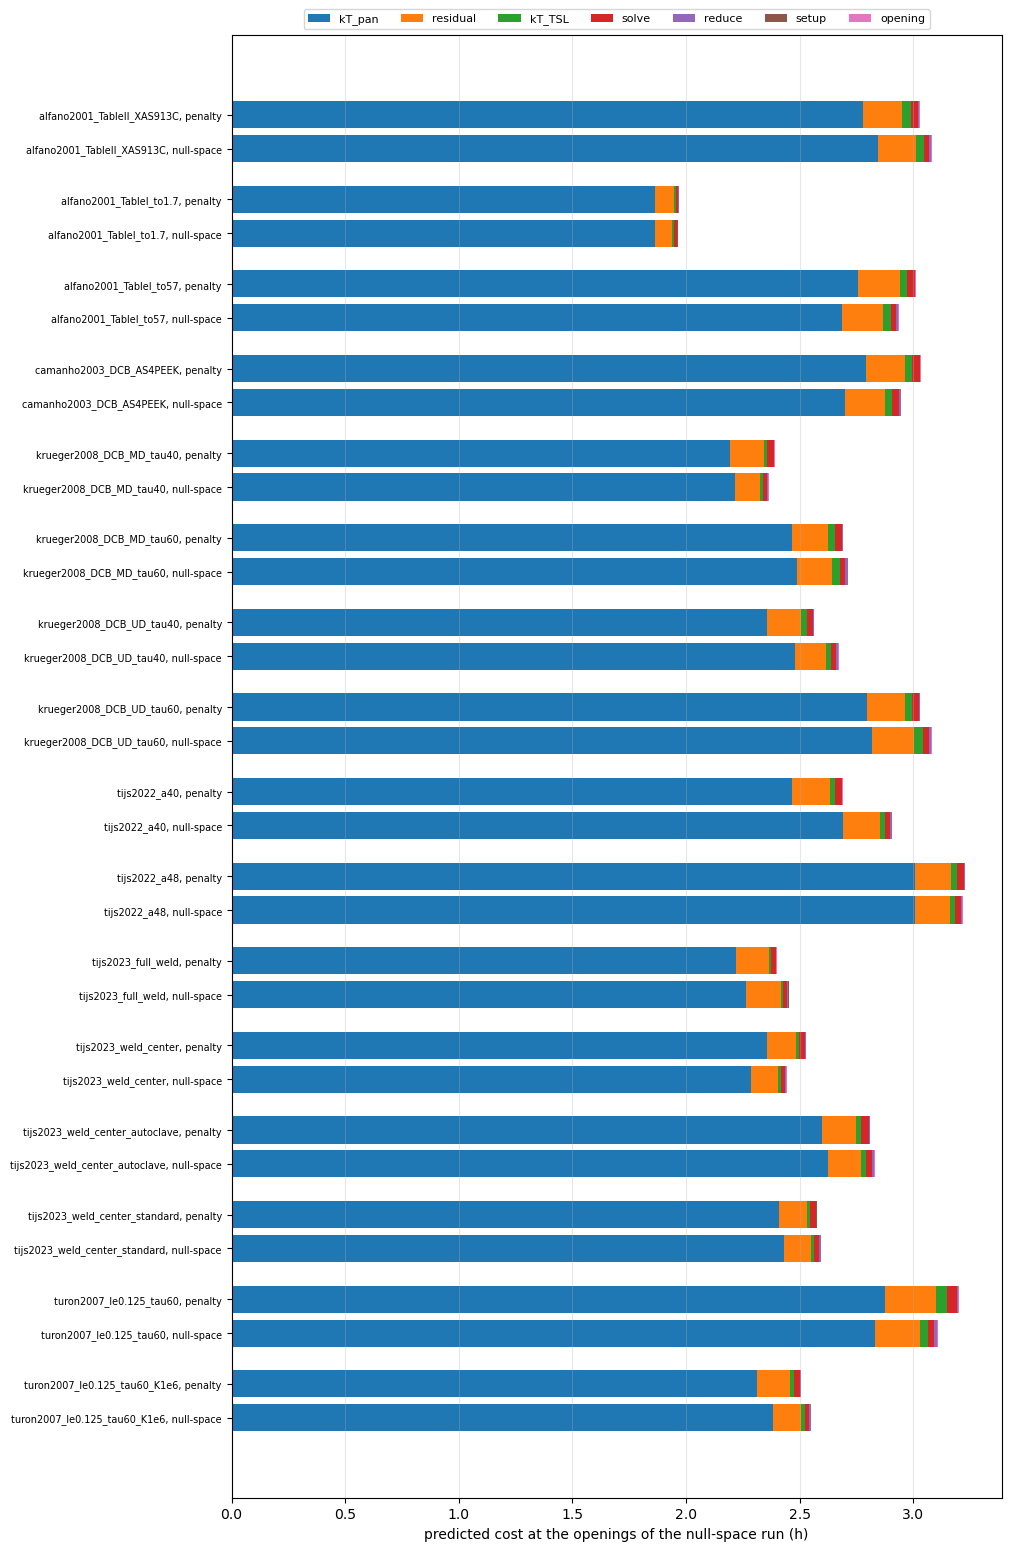

Share of the components in the predicted cost of all the cases above:

| component | penalty (%) | null-space (%) |
|---|---|---|
| `kT_pan` | 92.20 | 92.59 |
| `residual` | 5.66 | 5.38 |
| `kT_TSL` | 0.89 | 0.87 |
| `solve` | 1.09 | 0.79 |
| `reduce` | 0.09 | 0.29 |
| `setup` | 0.00 | 0.00 |
| `opening` | 0.07 | 0.07 |

In [9]:
COMP = ('kT_pan', 'residual', 'kT_TSL', 'solve', 'reduce', 'setup', 'opening')
def trunc(r, k):
    return {kk: (np.asarray(v)[:k] if np.ndim(v) else v) for kk, v in r.items()}

pred = {}
rows = ['| case | openings | iterations penalty / null-space | `kT_pan` calls penalty / null-space '
        '| penalty (h) | null-space (h) | diff. (%) | same iterations, diff. (%) | `kT_pan` share (%) |',
        '|---|---|---|---|---|---|---|---|---|']
for name in names:
    rp, rn = res[name]['penalty'], res[name]['null']
    if rn is None:
        continue
    k = len(rn['iters'])
    rp = trunc(rp, k)
    kT = 0.5*(IT[name + '|penalty']['t']['kT_pan'] + IT[name + '|null-space']['t']['kT_pan'])
    npn, nnn = study.iteration_counts(rp, bond[name]), study.iteration_counts(rn, bond[name])
    cp = study.predicted_cost(IT[name + '|penalty'], npn, kT)
    cn = study.predicted_cost(IT[name + '|null-space'], nnn, kT)
    cs = study.predicted_cost(IT[name + '|null-space'], npn, kT)
    pred[name] = dict(penalty=cp, null=cn, k=k)
    Tp, Tn, Ts = (sum(c.values()) for c in (cp, cn, cs))
    rows.append(f"| {name} | {k} | {npn['iter']} / {nnn['iter']} | {npn['kT_pan']} / {nnn['kT_pan']} "
                f"| {Tp/3600:.2f} | {Tn/3600:.2f} | {pct(Tn, Tp):+.1f} | {pct(Ts, Tp):+.2f} | {100*cp['kT_pan']/Tp:.1f} |")
display(Markdown('\n'.join(rows)))

fig, ax = plt.subplots(figsize=(10, 0.45*2*len(pred) + 1), constrained_layout=True)
labels, y = [], 0
for name, d in pred.items():
    for m, key in (('penalty', 'penalty'), ('null-space', 'null')):
        left = 0.
        for i, comp in enumerate(COMP):
            v = d[key][comp]/3600
            ax.barh(y, v, left=left, color='C%d' % i, label=comp if y == 0 else None)
            left += v
        labels.append(f'{name}, {m}')
        y += 1
    y += 0.5
ax.set_yticks([i + 0.5*(i//2) for i in range(len(labels))])
ax.set_yticklabels(labels, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('predicted cost at the openings of the null-space run (h)')
ax.legend(fontsize=8, ncol=len(COMP), loc='lower center', bbox_to_anchor=(0.5, 1.0))
ax.grid(True, axis='x', alpha=0.3)
plt.show()

tot = {m: {c: sum(d[m][c] for d in pred.values()) for c in COMP} for m in ('penalty', 'null')}
rows = ['| component | penalty (%) | null-space (%) |', '|---|---|---|']
for c in COMP:
    rows.append(f"| `{c}` | {100*tot['penalty'][c]/sum(tot['penalty'].values()):.2f} | {100*tot['null'][c]/sum(tot['null'].values()):.2f} |")
display(Markdown('Share of the components in the predicted cost of all the cases above:\n\n' + '\n'.join(rows)))

### Measured wall times

The ratio between the measured wall time and the predicted cost of each run measures the load of the machine during the run, rather than the method: it is about the same for the runs of a batch, whatever the case.

In [10]:
rows = ['| case | stored penalty run: time (h), measured / predicted | penalty rerun: openings, measured / predicted '
        '| null-space run: openings, time (h), measured / predicted |', '|---|---|---|---|']
for name in names:
    p = IT[name + '|penalty']
    kT = 0.5*(p['t']['kT_pan'] + IT[name + '|null-space']['t']['kT_pan'])
    ratio = lambda r, prof: float(r['time'])/sum(study.predicted_cost(prof, study.iteration_counts(r, bond[name]), kT).values())
    rp = res[name]['penalty']
    cells_ = [f"{float(rp['time'])/3600:.2f}, {ratio(rp, p):.2f}"]
    f = os.path.join(study.method_dir('penalty'), name + '.npz')
    if os.path.exists(f):
        rr = du.load(f)
        cells_.append(f"{len(rr['iters'])}, {ratio(rr, p):.2f}")
    else:
        cells_.append('-')
    rn = res[name]['null']
    if rn is not None:
        cells_.append(f"{len(rn['iters'])}{'' if complete(rn, [j for j in jobs if j['name'] == name][0]) else '*'}, "
                      f"{float(rn['time'])/3600:.2f}, {ratio(rn, IT[name + '|null-space']):.2f}")
    else:
        cells_.append('-')
    rows.append(f"| {name} | " + ' | '.join(cells_) + ' |')
display(Markdown('\n'.join(rows) + '\n\n\\* run not complete'))

| case | stored penalty run: time (h), measured / predicted | penalty rerun: openings, measured / predicted | null-space run: openings, time (h), measured / predicted |
|---|---|---|---|
| alfano2001_TableII_XAS913C | 2.15, 0.71 | - | 60, 3.44, 1.12 |
| alfano2001_TableI_to1.7 | 7.36, 3.74 | 23, 0.82 | 40, 2.22, 1.13 |
| alfano2001_TableI_to57 | 2.63, 0.87 | 33, 0.83 | 60, 3.18, 1.08 |
| camanho2003_DCB_AS4PEEK | 2.64, 0.87 | 30, 0.83 | 60, 3.12, 1.06 |
| krueger2008_DCB_MD_tau40 | 1.51, 0.63 | - | 60, 2.12, 0.90 |
| krueger2008_DCB_MD_tau60 | 1.78, 0.66 | - | 60, 2.48, 0.91 |
| krueger2008_DCB_UD_tau40 | 1.79, 0.70 | - | 60, 2.68, 1.00 |
| krueger2008_DCB_UD_tau60 | 1.98, 0.65 | - | 60, 2.91, 0.94 |
| tijs2022_a40 | 2.24, 0.83 | - | 60, 3.22, 1.11 |
| tijs2022_a48 | 2.43, 0.75 | - | 60, 3.27, 1.01 |
| tijs2023_full_weld | 2.00, 0.83 | - | 60, 2.16, 0.88 |
| tijs2023_weld_center | 2.08, 0.82 | - | 60, 2.18, 0.89 |
| tijs2023_weld_center_autoclave | 2.29, 0.81 | - | 60, 3.05, 1.08 |
| tijs2023_weld_center_standard | 2.13, 0.83 | - | 60, 2.36, 0.91 |
| turon2007_le0.125_tau60 | 2.72, 0.85 | 30, 0.81 | 60, 3.29, 1.06 |
| turon2007_le0.125_tau60_K1e6 | 1.82, 0.73 | - | 60, 2.32, 0.91 |

\* run not complete

In [11]:
def rng(v, f='%.1f'):
    v = np.asarray(list(v), dtype=float)
    return (f + ' to ' + f) % (v.min(), v.max())

share_kT = [100*d['penalty']['kT_pan']/sum(d['penalty'].values()) for d in pred.values()] + \
           [100*d['null']['kT_pan']/sum(d['null'].values()) for d in pred.values()]
share_tsl = [100*sum(r['t_kC'] + r['t_kG'] for r in pans if r['tsl'])/sum(r['t_kC'] + r['t_kG'] for r in pans)
             for pans in PR['panels'].values()]
P_, N_ = [IT[nm + '|penalty'] for nm in names], [IT[nm + '|null-space'] for nm in names]
removed = [p['size'] - n['size_r'] for p, n in zip(P_, N_)]
nnz = [pct(n['nnz_k0'], p['nnz_k0']) for p, n in zip(P_, N_)]
solve_ = [pct(n['t']['solve'], p['t']['solve']) for p, n in zip(P_, N_)]
red_ = [per_red(n['t']) for n in N_]
tT = [n['t_T'] for n in N_]
diff_same, diff = [], []
it_p = it_n = 0
for name, d in pred.items():
    rp = trunc(res[name]['penalty'], d['k'])
    kT = 0.5*(IT[name + '|penalty']['t']['kT_pan'] + IT[name + '|null-space']['t']['kT_pan'])
    npn = study.iteration_counts(rp, bond[name])
    Ts = sum(study.predicted_cost(IT[name + '|null-space'], npn, kT).values())
    Tp, Tn = sum(d['penalty'].values()), sum(d['null'].values())
    diff_same.append(pct(Ts, Tp))
    diff.append(pct(Tn, Tp))
    it_p += int(np.sum(rp['iters']))
    it_n += int(np.sum(res[name]['null']['iters']))
share_res = [100*d[m]['residual']/sum(d[m].values()) for d in pred.values() for m in ('penalty', 'null')]
display(Markdown(f'''**Summary of the cost**

- The cost of the DCB runs is the tangent stiffness of the panels, `kT_pan`, {rng(share_kT)} % of the predicted cost, and within it the numerical integration of the two cohesive-zone panels, {rng(share_tsl)} % of `kT_pan`: they have 25 x 10 terms integrated on 50 x 20 points, against 8 x 8 terms on 16 x 16 points for the other panels. This computation is the same with both methods.
- The null-space method removes {rng(removed, '%d')} of the unknowns, but only {rng(np.negative(nnz))} % of the nonzeros of the system, which are dominated by the full coupling of the cohesive-zone panels by `'SB_TSL'`, a penalty stiffness with both methods. The sparse solution is {rng(np.negative(solve_), '%.0f')} % faster and `get_kC_conn` no longer computes the edge penalties, while $T^T K T$ adds {rng(red_, '%.2f')} s per iteration. The basis $T$ is built once, in {rng(tT, '%.3f')} s.
- With the same iterations, the predicted cost of the null-space runs differs from that of the penalty runs by {rng(diff_same, '%+.2f')} %. The runs differ more by their numbers of iterations, {it_p} for the penalty runs against {it_n} for the null-space runs over the openings compared, giving {rng(diff, '%+.1f')} % case by case: the Newton-Raphson iterations follow slightly different paths, without a systematic trend.
- The measured wall times are not a measure of the method: the ratio measured / predicted of the table above is about the same for the runs made together, the penalty reruns or the null-space runs, whatever the case, and varies between the stored runs, made by the notebooks at different times. The residual is {rng(share_res)} % of the predicted cost, with one trial of the line search per iteration, so that twice as many trials, whose number is not stored, would change the cost of a run by less than that, far less than the difference between the ratios of the null-space runs and of the penalty reruns, which comes from the load of the machine: 8 runs on the 8 cores, partly with the profiling, against 7 runs.
- Any significant reduction of the cost of these runs must come from the tangent of the cohesive-zone panels, not from the connections.'''))

**Summary of the cost**

- The cost of the DCB runs is the tangent stiffness of the panels, `kT_pan`, 89.8 to 94.9 % of the predicted cost, and within it the numerical integration of the two cohesive-zone panels, 97.4 to 98.7 % of `kT_pan`: they have 25 x 10 terms integrated on 50 x 20 points, against 8 x 8 terms on 16 x 16 points for the other panels. This computation is the same with both methods.
- The null-space method removes 80 to 320 of the unknowns, but only 3.3 to 7.7 % of the nonzeros of the system, which are dominated by the full coupling of the cohesive-zone panels by `'SB_TSL'`, a penalty stiffness with both methods. The sparse solution is 13 to 41 % faster and `get_kC_conn` no longer computes the edge penalties, while $T^T K T$ adds 0.14 to 0.19 s per iteration. The basis $T$ is built once, in 0.009 to 0.040 s.
- With the same iterations, the predicted cost of the null-space runs differs from that of the penalty runs by -2.04 to +0.89 %. The runs differ more by their numbers of iterations, 2828 for the penalty runs against 2859 for the null-space runs over the openings compared, giving -3.4 to +8.1 % case by case: the Newton-Raphson iterations follow slightly different paths, without a systematic trend.
- The measured wall times are not a measure of the method: the ratio measured / predicted of the table above is about the same for the runs made together, the penalty reruns or the null-space runs, whatever the case, and varies between the stored runs, made by the notebooks at different times. The residual is 3.9 to 7.0 % of the predicted cost, with one trial of the line search per iteration, so that twice as many trials, whose number is not stored, would change the cost of a run by less than that, far less than the difference between the ratios of the null-space runs and of the penalty reruns, which comes from the load of the machine: 8 runs on the 8 cores, partly with the profiling, against 7 runs.
- Any significant reduction of the cost of these runs must come from the tangent of the cohesive-zone panels, not from the connections.

## Stamatelos and Labeas (2023): buckling of divided and stiffened plates

`stamatelos_labeas_2023_multidomain.ipynb` executed with both methods: `'SSxcte'` and `'SSycte'` strips, `'SB'` bonded sub-laminates and `'BFycte'`/`'BFxcte'` plate blades. The penalty runs use the penalty factors of the notebook, the null-space runs ignore them. The eigenvalues are in N/m, and the single-domain references are those of the notebook.

In [12]:
path = os.path.join(OUT, 'stamatelos.json')
S = json.load(open(path)) if os.path.exists(path) else None
if S is not None:
    P, N = S['penalty'], S['null-space']
    rows = ['| model | reference | penalty | diff. (%) | null-space | diff. (%) |', '|---|---|---|---|---|---|']
    ref = P['ref_sd']
    for along, func in (('y', 'SSycte'), ('x', 'SSxcte')):
        for f in ('0.1', '1', '10', '100', '1000'):
            ev = P['strips'][f'{along}_{f}']
            rows.append(f"| 3 {func} strips, mode 1, penalty x{f} | {ref[0]:.1f} | {ev[0]:.1f} | {pct(ev[0], ref[0]):+.4f} | | |")
        evn = N['strips'][f'{along}_1']
        rows.append(f"| 3 {func} strips, mode 1, null-space | {ref[0]:.1f} | | | {evn[0]:.1f} | {pct(evn[0], ref[0]):+.4f} |")
    for name, d in P['table2'].items():
        dn = N['table2'][name]
        rows.append(f"| Table 2 {name}, 3 SSxcte (N/mm) | {d['sd']:.4f} | {d['Nxx']:.4f} | {pct(d['Nxx'], d['sd']):+.4f} "
                    f"| {dn['Nxx']:.4f} | {pct(dn['Nxx'], dn['sd']):+.4f} |")
    for i in range(3):
        a, b, r = P['table3'][i], N['table3'][i], P['table3_sd'][i]
        rows.append(f"| Table 3 mode {i + 1}, 3 SSycte | {r:.1f} | {a:.1f} | {pct(a, r):+.4f} | {b:.1f} | {pct(b, r):+.4f} |")
    mono = P['sb_mono'][0]
    for k in P['sb']:
        a, b = P['sb'][k][0], N['sb'][k][0]
        rows.append(f"| bonded halves, {k}, mode 1 | {mono:.1f} | {a:.1f} | {pct(a, mono):+.4f} | {b:.1f} | {pct(b, mono):+.4f} |")
    for key, d in P['table45'].items():
        dn = N['table45'][key]
        for v in ('edge', 'interior', 'rotated'):
            if f'{v}_1' in d:
                rows.append(f"| Tables 4/5 {key}, blade {v} (N/mm) | {d['sd']:.2f} | {d[v + '_1']:.2f} | {pct(d[v + '_1'], d['sd']):+.2f} "
                            f"| {dn[v + '_1']:.2f} | {pct(dn[v + '_1'], dn['sd']):+.2f} |")
        if 'edge_100' in d:
            rows.append(f"| Tables 4/5 {key}, blade edge, penalty x100 | {d['sd']:.2f} | {d['edge_100']:.2f} | {pct(d['edge_100'], d['sd']):+.2f} | | |")
    display(Markdown('\n'.join(rows)))

| model | reference | penalty | diff. (%) | null-space | diff. (%) |
|---|---|---|---|---|---|
| 3 SSycte strips, mode 1, penalty x0.1 | 14297.9 | 12065.5 | -15.6134 | | |
| 3 SSycte strips, mode 1, penalty x1 | 14297.9 | 14010.3 | -2.0113 | | |
| 3 SSycte strips, mode 1, penalty x10 | 14297.9 | 14268.2 | -0.2071 | | |
| 3 SSycte strips, mode 1, penalty x100 | 14297.9 | 14294.9 | -0.0208 | | |
| 3 SSycte strips, mode 1, penalty x1000 | 14297.9 | 14297.6 | -0.0021 | | |
| 3 SSycte strips, mode 1, null-space | 14297.9 | | | 14297.9 | +0.0000 |
| 3 SSxcte strips, mode 1, penalty x0.1 | 14297.9 | 13269.5 | -7.1922 | | |
| 3 SSxcte strips, mode 1, penalty x1 | 14297.9 | 14250.9 | -0.3287 | | |
| 3 SSxcte strips, mode 1, penalty x10 | 14297.9 | 14293.1 | -0.0331 | | |
| 3 SSxcte strips, mode 1, penalty x100 | 14297.9 | 14297.4 | -0.0033 | | |
| 3 SSxcte strips, mode 1, penalty x1000 | 14297.9 | 14297.8 | -0.0003 | | |
| 3 SSxcte strips, mode 1, null-space | 14297.9 | | | 14297.9 | +0.0000 |
| Table 2 [0_3/90_3]s, 3 SSxcte (N/mm) | 27.1520 | 27.1504 | -0.0059 | 27.1520 | +0.0000 |
| Table 2 [0_3/90_3/0_3/90_3], 3 SSxcte (N/mm) | 17.2571 | 17.2564 | -0.0042 | 17.2571 | +0.0000 |
| Table 2 [0_2/45_2/0_2/45_2/0_2], 3 SSxcte (N/mm) | 15.9435 | 15.9427 | -0.0048 | 15.9435 | +0.0003 |
| Table 2 [0_2/45_2/0_2/-45_2/0_2], 3 SSxcte (N/mm) | 15.0281 | 15.0274 | -0.0049 | 15.0281 | +0.0000 |
| Table 2 [0_6/60_6], 3 SSxcte (N/mm) | 12.1101 | 12.1102 | +0.0008 | 12.1106 | +0.0039 |
| Table 3 mode 1, 3 SSycte | 14297.9 | 14294.9 | -0.0208 | 14297.9 | +0.0000 |
| Table 3 mode 2, 3 SSycte | 14655.6 | 14654.7 | -0.0064 | 14655.6 | +0.0000 |
| Table 3 mode 3, 3 SSycte | 23840.2 | 23839.5 | -0.0029 | 23840.2 | +0.0002 |
| bonded halves, SB, top first, mode 1 | 17317.2 | 17308.7 | -0.0494 | 17317.2 | +0.0000 |
| bonded halves, SB, bottom first, mode 1 | 17317.2 | 17308.7 | -0.0494 | 17317.2 | -0.0000 |
| bonded halves, SB_TSL, top first, mode 1 | 17317.2 | 17308.6 | -0.0496 | 17308.6 | -0.0496 |
| bonded halves, SB_TSL, bottom first, mode 1 | 17317.2 | 17308.6 | -0.0496 | 17308.6 | -0.0496 |
| Tables 4/5 table4/uniform, blade edge (N/mm) | 115.22 | 119.62 | +3.82 | 119.75 | +3.93 |
| Tables 4/5 table4/uniform, blade interior (N/mm) | 115.22 | 119.78 | +3.96 | 119.89 | +4.05 |
| Tables 4/5 table4/uniform, blade rotated (N/mm) | 115.22 | 119.62 | +3.82 | 119.75 | +3.93 |
| Tables 4/5 table4/uniform, blade edge, penalty x100 | 115.22 | 119.75 | +3.93 | | |
| Tables 4/5 table4/triangular, blade edge (N/mm) | 175.78 | 178.33 | +1.45 | 179.12 | +1.90 |
| Tables 4/5 table4/triangular, blade interior (N/mm) | 175.78 | 179.45 | +2.09 | 179.57 | +2.15 |
| Tables 4/5 table4/triangular, blade rotated (N/mm) | 175.78 | 178.33 | +1.45 | 179.12 | +1.90 |
| Tables 4/5 table4/triangular, blade edge, penalty x100 | 175.78 | 179.11 | +1.89 | | |
| Tables 4/5 table5/uniform, blade edge (N/mm) | 115.22 | 117.84 | +2.28 | 117.89 | +2.32 |
| Tables 4/5 table5/uniform, blade interior (N/mm) | 115.22 | 117.90 | +2.32 | 117.93 | +2.35 |
| Tables 4/5 table5/uniform, blade rotated (N/mm) | 115.22 | 117.84 | +2.28 | 117.89 | +2.32 |
| Tables 4/5 table5/uniform, blade edge, penalty x100 | 115.22 | 117.89 | +2.31 | | |
| Tables 4/5 table5/triangular, blade edge (N/mm) | 175.77 | 175.78 | +0.00 | 176.59 | +0.47 |
| Tables 4/5 table5/triangular, blade interior (N/mm) | 175.77 | 176.89 | +0.64 | 176.91 | +0.65 |
| Tables 4/5 table5/triangular, blade rotated (N/mm) | 175.77 | 175.78 | +0.00 | 176.59 | +0.47 |
| Tables 4/5 table5/triangular, blade edge, penalty x100 | 175.77 | 176.58 | +0.46 | | |

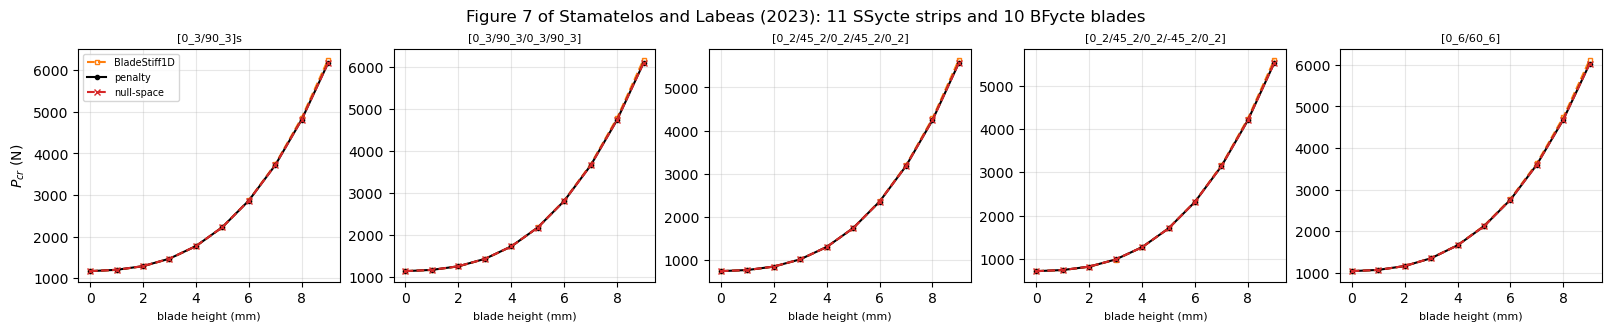

| lamination | max. diff. null-space vs penalty (%) | max. diff. penalty vs BladeStiff1D (%) | max. diff. null-space vs BladeStiff1D (%) |
|---|---|---|---|
| [0_3/90_3]s | 0.01 | 1.3 | 1.3 |
| [0_3/90_3/0_3/90_3] | 0.02 | 1.3 | 1.3 |
| [0_2/45_2/0_2/45_2/0_2] | 0.01 | 1.3 | 1.3 |
| [0_2/45_2/0_2/-45_2/0_2] | 0.01 | 1.3 | 1.3 |
| [0_6/60_6] | 0.01 | 1.5 | 1.5 |

notebook run time: penalty 303 s, null-space 350 s


In [13]:
if S is not None:
    heights = np.linspace(0., 9., 10)
    fig, axes = plt.subplots(1, len(P['figure7']), figsize=(16, 3.2), constrained_layout=True)
    rows = ['| lamination | max. diff. null-space vs penalty (%) | max. diff. penalty vs BladeStiff1D (%) | max. diff. null-space vs BladeStiff1D (%) |',
            '|---|---|---|---|']
    for ax, (name, d) in zip(axes, P['figure7'].items()):
        dn = N['figure7'][name]
        pm, pn, sd = map(np.array, (d['P_md'], dn['P_md'], d['P_sd']))
        ax.plot(heights, sd, 's--', ms=3, mfc='none', color='C1', label='BladeStiff1D')
        ax.plot(heights, pm, 'o-', ms=3, color='k', label='penalty')
        ax.plot(heights, pn, 'x--', ms=4, color='C3', label='null-space')
        ax.set_title(name, fontsize=8)
        ax.set_xlabel('blade height (mm)', fontsize=8)
        ax.grid(True, alpha=0.3)
        rows.append(f"| {name} | {np.abs(pct(pn, pm)).max():.2f} | {np.abs(pct(pm, sd)).max():.1f} | {np.abs(pct(pn, sd)).max():.1f} |")
    axes[0].set_ylabel('$P_{cr}$ (N)')
    axes[0].legend(fontsize=7)
    fig.suptitle('Figure 7 of Stamatelos and Labeas (2023): 11 SSycte strips and 10 BFycte blades')
    plt.show()
    display(Markdown('\n'.join(rows)))
    print('notebook run time: penalty %.0f s, null-space %.0f s' % (P['time'], N['time']))

## Discussion

**DCB.** The 16 cases, 7 notebooks, were run to the last opening with both methods, without bisections of the increments:

- the peak loads of the two methods agree within 0.03 %, and the load-opening curves within 0.12 % of the peak load before the peak and 0.23 % after it;
- the crack growth at the last opening is the same, within 0.1 mm, or 0.2 mm for `turon2007_le0.125_tau60_K1e6`;
- the null-space models are slightly stiffer, the initial stiffness by 0.07 % to 0.16 % and the elastic compliances lower by 0.13 % to 0.21 %: the connections `'SSxcte'` and `'SB'` are exact, while their penalty stiffnesses, 100 times the default of `calc_kt_kr` for the edges, leave a small compliance.

The penalty stiffnesses of `dcb_utils.build_dcb` are therefore adequate for these benchmarks: they change the stiffness by about 0.1 % to 0.2 % and the peak loads by less than 0.03 %, which is negligible for these benchmarks. The null-space method gives these results without a penalty factor to choose.

**Stamatelos and Labeas (2023).** For the strips connected by `'SSycte'` or `'SSxcte'`, the plates of Tables 2 and 3 and the laminates bonded by `'SB'`, the null-space method reproduces the single-domain eigenvalues to within 0.004 %, whereas the penalty results depend on the penalty factor: -15.6 % at 0.1 times the default stiffness of the `'SSycte'` strips, -2.0 % at the default and -0.02 % at 100 times the default. For the plate blades connected by `'BFycte'` and `'BFxcte'`, the null-space results are the limit of the penalty results, equal to those at 100 times the default penalty within 0.01 %, while the default penalty differs from them by up to 0.46 %. The agreement of the default penalty with the reference for the triangular load of Table 5, +0.00 %, is therefore a compensation of errors: the converged model is 0.47 % stiffer than the reference. The remaining differences to the references of Tables 4 and 5, up to 3.9 %, and of Figure 7, 1.3 % to 1.5 %, are those of the models, not of the connections. The `'SB_TSL'` connection is a penalty stiffness in both cases, and gives the same results.

**Cost.** See the summary of the cost above: the cost of the DCB runs is the tangent stiffness of the cohesive-zone panels, the same with both methods, and with the same iterations the null-space runs cost from 2 % less to 1 % more. The runs of the Stamatelos notebook took 350 s with the null-space method against 303 s with the penalty method, each measured once; this notebook has many small models, for which building $T$ and the products $T^T K T$ of the eigenvalue problems are not negligible, and it was not profiled.

**Conclusion.** The null-space method gives the results of the penalty method in the limit of an infinite penalty stiffness, with no penalty factor to choose and no loss of conditioning, and at the same cost in the DCB benchmarks. Where the penalty stiffnesses of the notebooks are large enough, as in the DCB benchmarks, both methods agree within 0.2 %; where they are not, the penalty results depend on the factor, while the null-space results do not.